<a href="https://colab.research.google.com/github/AhmedEsammohmaed/IBS/blob/main/IBS_cubic_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("qmarva/cubicasa5k")

100%|██████████| 5.10G/5.10G [00:55<00:00, 98.8MB/s]

Extracting files...


In [3]:
import sys
import os
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("GPU: Not available")
except ImportError:
    print("PyTorch is not installed.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cpu
CUDA available: False
GPU: Not available


In [5]:
!pip -q install kaggle opencv-python matplotlib pillow numpy pandas lxml svgwrite

In [6]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

Saving kaggle_CV.json to kaggle_CV.json
Uploaded files: ['kaggle_CV.json']


In [11]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("kaggle_CV.json"):
    shutil.copy("kaggle_CV.json", "/root/.kaggle/kaggle_CV.json")
    os.chmod("/root/.kaggle/kaggle_CV.json", 0o600)
    print("Kaggle API configured successfully.")
else:
    raise FileNotFoundError(
        "kaggle.json was not found. Run the previous cell and upload it."
    )

Kaggle API configured successfully.


In [12]:
!kaggle datasets list -s cubicasa5k

ref                                      title                            size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------  -------------------------  ----------  --------------------------  -------------  ---------  ---------------  
qmarva/cubicasa5k                        CubiCasa5k                 5479650216  2024-09-27 23:43:10.367000           5976         30  0.8125           
ildarlukmanov/cubicasa5k-yolo-formatted  CubiCasa5k-YOLO-Formatted  2030470631  2026-01-09 20:06:34.523000             94          0  0.4375           
harshilsanganiii/cubicasa5k-yolo         Cubicasa5k_yolo            1896303482  2026-02-24 06:18:19.420000             16          0  0.25             
xiasky/cubiacasa5kmaster                 cubiacasa5kmaster          5738865155  2022-06-24 13:33:11.030000            118          3  0.3125           


In [13]:
from pathlib import Path

PROJECT_DIR = Path("/content/ibs_cv")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs"
VIS_DIR = OUTPUT_DIR / "visualizations"

for directory in [
    PROJECT_DIR,
    DATA_DIR,
    RAW_DIR,
    OUTPUT_DIR,
    VIS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw dataset directory:", RAW_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /content/ibs_cv
Raw dataset directory: /content/ibs_cv/data/raw
Output directory: /content/ibs_cv/outputs


In [14]:
DATASET = "qmarva/cubicasa5k"

!kaggle datasets download \
    -d {DATASET} \
    -p {RAW_DIR} \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/qmarva/cubicasa5k
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
100% 5.10G/5.10G [01:07<00:00, 81.1MB/s]



In [15]:
from pathlib import Path

def print_tree(root, max_depth=3):
    root = Path(root)

    for path in sorted(root.rglob("*")):
        relative = path.relative_to(root)
        depth = len(relative.parts) - 1

        if depth <= max_depth:
            indent = "    " * depth
            prefix = "📁" if path.is_dir() else "📄"
            print(f"{indent}{prefix} {path.name}")

print_tree(RAW_DIR, max_depth=3)

Streaming output truncated to the last 5000 lines.
            📁 10481
            📁 10611
            📁 10706
            📁 10709
            📁 10711
            📁 1077
            📁 10777
            📁 11031
            📁 11044
            📁 11104
            📁 11128
            📁 11191
            📁 11192
            📁 11193
            📁 11194
            📁 11195
            📁 11196
            📁 11260
            📁 11261
            📁 11395
            📁 11397
            📁 11398
            📁 11399
            📁 11400
            📁 11402
            📁 1148
            📁 11485
            📁 11527
            📁 11565
            📁 11573
            📁 11578
            📁 11664
            📁 11750
            📁 11752
            📁 11773
            📁 11774
            📁 11859
            📁 11867
            📁 1194
            📁 11960
            📁 11962
            📁 12002
            📁 12030
            📁 12094
            📁 12139
            📁 12200
            📁 12202
            

In [16]:
from collections import Counter

extensions = Counter()

for path in RAW_DIR.rglob("*"):
    if path.is_file():
        suffix = path.suffix.lower() or "[no extension]"
        extensions[suffix] += 1

print("File counts by extension:")
print("-" * 40)

for ext, count in sorted(extensions.items()):
    print(f"{ext:15} {count:,}")

File counts by extension:
----------------------------------------
.json           3
.png            12,342
.svg            5,000
.txt            3


In [17]:
image_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

image_files = sorted(
    [
        p for p in RAW_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
)

print("Number of image files:", len(image_files))

print("\nFirst 20 images:")
for path in image_files[:20]:
    print(path)

Number of image files: 12342

First 20 images:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_original.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_scaled.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10062/F1_original.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10062/F1_scaled.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/F1_original.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/F1_scaled.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/F2_original.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/F2_scaled.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1012/F1_original.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1012/F1_scaled.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10266/F1_original.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10266/F1_scaled.png
/content/ibs_cv/data/raw/cubica

In [18]:
from PIL import Image
from collections import Counter

dimension_counts = Counter()
failed_images = []

for path in image_files:
    try:
        with Image.open(path) as img:
            dimension_counts[img.size] += 1
    except Exception as e:
        failed_images.append((str(path), str(e)))

print("Unique image dimensions:", len(dimension_counts))

print("\nMost common dimensions:")
for size, count in dimension_counts.most_common(20):
    print(f"{size}: {count:,}")

print("\nImages that failed to open:", len(failed_images))

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90344064 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Unique image dimensions: 9773

Most common dimensions:
(2730, 2048): 32
(4000, 3000): 30
(2480, 3507): 21
(3507, 2480): 16
(1600, 1200): 12
(579, 434): 10
(512, 384): 10
(800, 600): 8
(600, 450): 7
(2640, 1320): 7
(2282, 2835): 6
(1086, 1222): 6
(2665, 2999): 6
(1112, 834): 5
(567, 596): 5
(971, 562): 5
(4960, 3507): 5
(869, 652): 4
(2338, 1653): 4
(3506, 2480): 4

Images that failed to open: 0


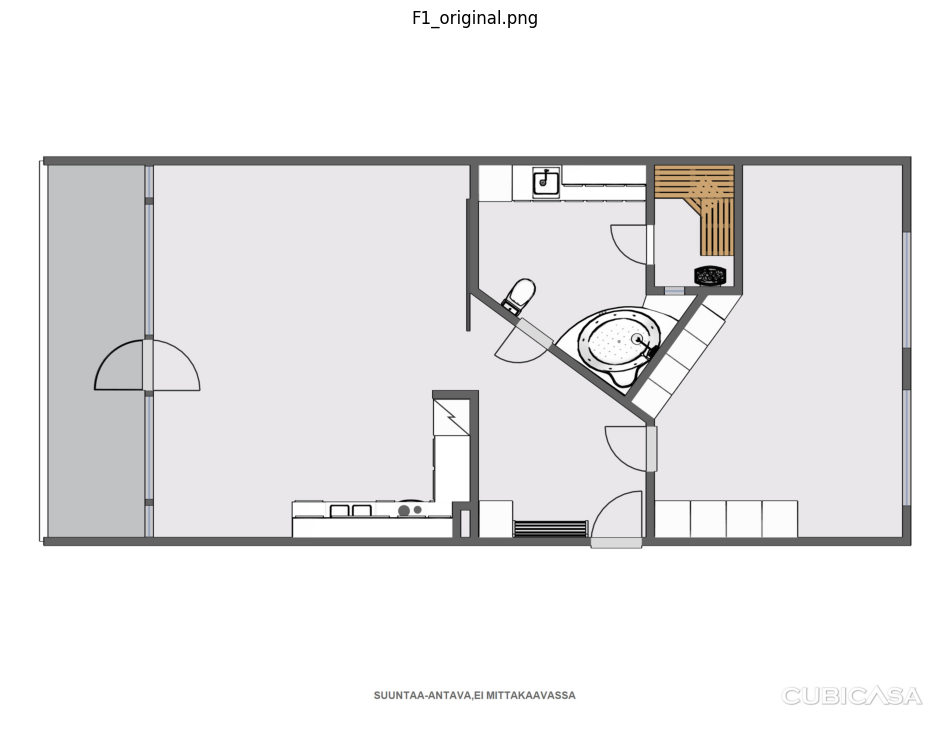

Image: /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_original.png
Size: (2730, 2048)


In [19]:
import matplotlib.pyplot as plt
from PIL import Image

if not image_files:
    raise RuntimeError("No image files were found.")

sample_image = image_files[0]

img = Image.open(sample_image).convert("RGB")

plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title(sample_image.name)
plt.show()

print("Image:", sample_image)
print("Size:", img.size)

In [20]:
annotation_extensions = {
    ".svg",
    ".json",
    ".xml",
    ".txt",
    ".csv"
}

annotation_files = sorted(
    [
        p for p in RAW_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in annotation_extensions
    ]
)

print("Potential annotation files:", len(annotation_files))

print("\nFirst 50:")
for path in annotation_files[:50]:
    print(path)

Potential annotation files: 5006

First 50:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10062/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1012/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10266/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10312/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10315/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1042/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10469/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10481/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10611/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10706/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10709/model.svg
/content/ibs_cv/data/r

In [21]:
svg_files = [
    p for p in annotation_files
    if p.suffix.lower() == ".svg"
]

print("SVG files:", len(svg_files))

if svg_files:
    sample_svg = svg_files[0]

    print("\nSample SVG:")
    print(sample_svg)

    with open(sample_svg, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()

    print("\nFirst 3000 characters:\n")
    print(content[:3000])
else:
    print("No SVG annotations found.")

SVG files: 5000

Sample SVG:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg

First 3000 characters:

<?xml version="1.0"?>
<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" height="855.0999755859375" version="1.1" width="1500.9399223327637" id="temp" viewBox="0 0 1500.9399223327637 855.0999755859375"><defs/><g id="Model" class="Model v1-1"><g class="Floor"><g id="Floor-1" class="Floorplan Floor-1"><g id="e28cc4ce-9494-4014-9427-ba6a5ee22214" fill="#ffffff" stroke="#000000" style="fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;" class="Space Outdoor"><polygon points="225.03,221.25 63.02,221.25 63.02,841.10 225.03,841.10 225.03,221.25 "/><g transform="matrix(1,0,0,1,63.0187,221.2541)" class="Dimension"><g transform="matrix(1,0,0,1,0,0)" style="display: none;" class="Visual"><g id="mark1" fill="#000000" stroke="none" transform="matrix(1,0,0,1,81.0055,0)" style="fill-opacity: 1; pointer-events: visible;" class="DimensionMark"

In [22]:
import json
from datetime import datetime

report = {
    "inspection_time": datetime.utcnow().isoformat() + "Z",
    "dataset": DATASET,
    "project_directory": str(PROJECT_DIR),
    "num_images": len(image_files),
    "num_annotation_candidates": len(annotation_files),
    "image_extensions": sorted(
        {p.suffix.lower() for p in image_files}
    ),
    "annotation_extensions": sorted(
        {p.suffix.lower() for p in annotation_files}
    ),
    "failed_images": failed_images,
    "image_dimensions": {
        f"{w}x{h}": count
        for (w, h), count in dimension_counts.items()
    }
}

report_path = OUTPUT_DIR / "dataset_inspection_report.json"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Report saved to:")
print(report_path)

Report saved to:
/content/ibs_cv/outputs/dataset_inspection_report.json


/tmp/ipykernel_760/2271149762.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "inspection_time": datetime.utcnow().isoformat() + "Z",


In [26]:
from pathlib import Path
from collections import defaultdict

# Show where our selected image actually is
print("Selected image:")
print(sample_image)

print("\nImage filename:")
print(sample_image.name)

print("\nImage stem:")
print(sample_image.stem)

print("\nParent directory:")
print(sample_image.parent)

# Show nearby files in the same directory
print("\nFiles in the same directory:")
for p in sorted(sample_image.parent.iterdir()):
    print(" ", p.name)

Selected image:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_original.png

Image filename:
F1_original.png

Image stem:
F1_original

Parent directory:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052

Files in the same directory:
  F1_original.png
  F1_scaled.png
  model.svg


In [27]:
# Search for annotation-like files near the selected image
annotation_extensions = {
    ".svg",
    ".json",
    ".xml",
    ".txt",
    ".csv"
}

print("Searching for annotation files...\n")

# First: same directory
same_dir_annotations = [
    p for p in sample_image.parent.iterdir()
    if p.is_file() and p.suffix.lower() in annotation_extensions
]

print("Annotations in same directory:")
for p in same_dir_annotations:
    print(" ", p)

# Second: nearby directories
nearby_annotations = []

for p in sample_image.parent.parent.rglob("*"):
    if p.is_file() and p.suffix.lower() in annotation_extensions:
        nearby_annotations.append(p)

print("\nNearby annotation candidates:")
for p in sorted(nearby_annotations)[:100]:
    print(" ", p)

print("\nTotal nearby candidates:", len(nearby_annotations))

Searching for annotation files...

Annotations in same directory:
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg

Nearby annotation candidates:
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10062/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1012/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10266/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10312/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10315/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1042/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10469/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10481/model.svg
  /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10611/model.svg
  /content/ibs_cv

In [28]:
# Print the first few directories containing files
print("Dataset directories:\n")

directories = sorted(
    {p.parent for p in RAW_DIR.rglob("*") if p.is_file()}
)

for directory in directories[:100]:
    print(directory)

Dataset directories:

/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10062
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1012
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10266
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10312
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10315
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1042
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10469
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10481
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10611
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10706
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10709
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10711
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1077
/con

In [29]:
from pathlib import Path

# Find a sample folder that contains model.svg
svg_files = sorted(
    RAW_DIR.glob("cubicasa5k/cubicasa5k/colorful/*/model.svg")
)

if not svg_files:
    raise FileNotFoundError("No model.svg files found.")

sample_svg = svg_files[0]
sample_folder = sample_svg.parent

print("Sample folder:")
print(sample_folder)

print("\nFiles inside sample folder:")
for p in sorted(sample_folder.iterdir()):
    print(f"{'DIR ' if p.is_dir() else 'FILE'} {p.name}")

Sample folder:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052

Files inside sample folder:
FILE F1_original.png
FILE F1_scaled.png
FILE model.svg


In [30]:
import xml.etree.ElementTree as ET

tree = ET.parse(sample_svg)
root = tree.getroot()

print("SVG file:")
print(sample_svg)

print("\nRoot:")
print(root.tag)

print("\nRoot attributes:")
for key, value in root.attrib.items():
    print(f"{key}: {value}")

print("\nNumber of XML elements:")
print(sum(1 for _ in root.iter()))

SVG file:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg

Root:
{http://www.w3.org/2000/svg}svg

Root attributes:
height: 855.0999755859375
version: 1.1
width: 1500.9399223327637
id: temp
viewBox: 0 0 1500.9399223327637 855.0999755859375

Number of XML elements:
524


In [31]:
from collections import Counter

element_counts = Counter()

for element in root.iter():
    tag = element.tag.split("}")[-1]
    element_counts[tag] += 1

print("SVG element types:")
print("-" * 40)

for tag, count in element_counts.most_common():
    print(f"{tag:20} {count}")

SVG element types:
----------------------------------------
g                    232
polygon              125
line                 65
text                 33
desc                 29
path                 19
circle               10
rect                 8
svg                  1
defs                 1
polyline             1


In [32]:
print("First annotated elements:")
print("=" * 70)

shown = 0

for element in root.iter():

    tag = element.tag.split("}")[-1]
    attrs = dict(element.attrib)

    # Ignore the SVG root unless it has useful information
    if tag == "svg":
        continue

    print("\nTAG:", tag)

    for key, value in attrs.items():
        print(f"  {key}: {value}")

    shown += 1

    if shown >= 30:
        break

First annotated elements:

TAG: defs

TAG: g
  id: Model
  class: Model v1-1

TAG: g
  class: Floor

TAG: g
  id: Floor-1
  class: Floorplan Floor-1

TAG: g
  id: e28cc4ce-9494-4014-9427-ba6a5ee22214
  fill: #ffffff
  stroke: #000000
  style: fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;
  class: Space Outdoor

TAG: polygon
  points: 225.03,221.25 63.02,221.25 63.02,841.10 225.03,841.10 225.03,221.25 

TAG: g
  transform: matrix(1,0,0,1,63.0187,221.2541)
  class: Dimension

TAG: g
  transform: matrix(1,0,0,1,0,0)
  style: display: none;
  class: Visual

TAG: g
  id: mark1
  fill: #000000
  stroke: none
  transform: matrix(1,0,0,1,81.0055,0)
  style: fill-opacity: 1; pointer-events: visible;
  class: DimensionMark

TAG: polygon
  points: -5,5,0,0,5,5

TAG: g
  id: mark2
  fill: #000000
  stroke: none
  transform: matrix(1,0,0,1,162.011,309.9218)
  style: fill-opacity: 1; pointer-events: visible;
  class: DimensionMark

TAG: polygon
  points: -5,-5,0,0,-5,5

TAG: g
  id: mark3
 

In [33]:
!pip -q install cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.1 MB/s eta 0:00:00


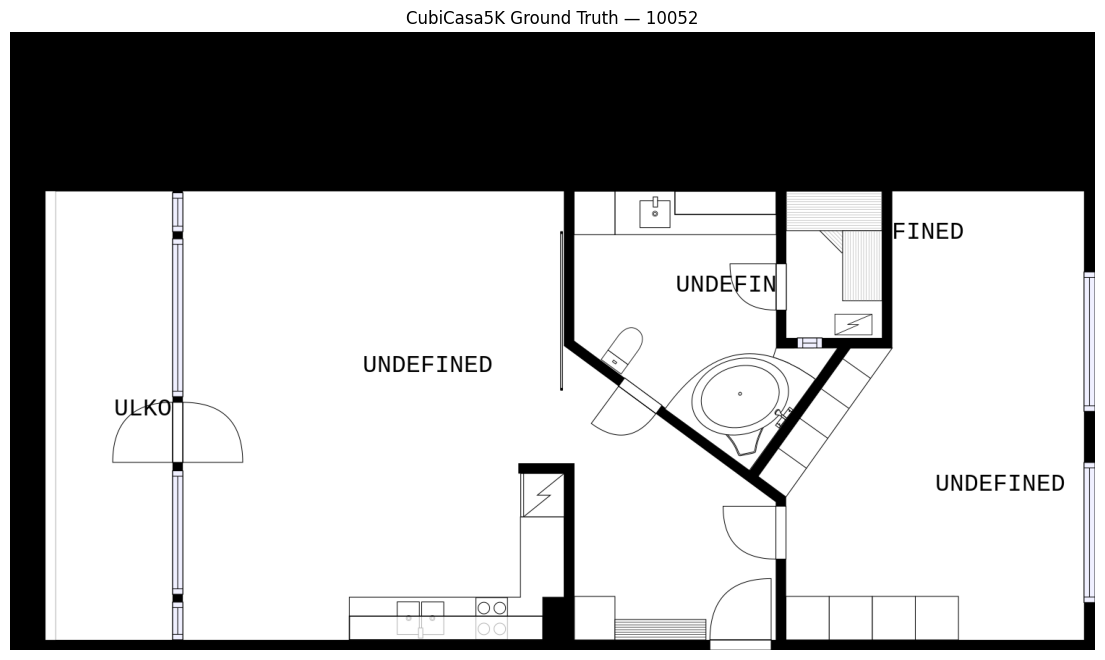

Rendered annotation size: (1501, 855)


In [34]:
import cairosvg
import io
import matplotlib.pyplot as plt
from PIL import Image

png_bytes = cairosvg.svg2png(
    url=str(sample_svg)
)

annotation_image = Image.open(
    io.BytesIO(png_bytes)
).convert("RGB")

plt.figure(figsize=(14, 12))
plt.imshow(annotation_image)
plt.axis("off")
plt.title(f"CubiCasa5K Ground Truth — {sample_folder.name}")
plt.show()

print("Rendered annotation size:", annotation_image.size)

In [35]:
from collections import Counter
import re

# Collect all attributes from SVG elements
attribute_values = Counter()

for element in root.iter():
    for key, value in element.attrib.items():
        attribute_values[(key, value)] += 1

print("Most common SVG attributes/values:")
print("=" * 70)

for (key, value), count in attribute_values.most_common(100):
    print(f"{key:20} {count:5}  {value}")

Most common SVG attributes/values:
stroke                  59  #000000
style                   46  display: none;
fill                    46  #000000
x1                      44  0
stroke                  42  none
fill                    41  #ffffff
fill-opacity            36  0.9
class                   29  BoundaryPolygon
style                   27  fill-opacity: 1; stroke-opacity: 1; stroke-width: 1;
style                   22  fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;
style                   20  fill-opacity: 1; pointer-events: visible;
class                   20  DimensionMark
fill                    20  none
class                   18  Direction
fill                    18  #444444
class                   18  Name
transform               18  translate(3 12)
font-size               18  12
font-family             18  Verdana, Sans-Serif
id                      16  Wall
x                       15  0
x2                      14  132.28790417615224
x2                      14

In [36]:
texts = []

for element in root.iter():
    tag = element.tag.split("}")[-1]

    if tag == "text":
        text = "".join(element.itertext()).strip()

        if text:
            texts.append({
                "text": text,
                "attributes": dict(element.attrib)
            })

print("Text elements found:", len(texts))

for item in texts[:100]:
    print(item)

Text elements found: 28
{'text': 'ULKOTILA', 'attributes': {'x': '0', 'y': '0em', 'fill': '#000000', 'stroke': 'none', 'style': 'font-family: Verdana; font-size: 33px; fill-opacity: 1; cursor: default;'}}
{'text': '5\'4" x 20\'4"', 'attributes': {'x': '0', 'y': '0em', 'fill': '#000000', 'stroke': 'none', 'style': 'font-family: Verdana; font-size: 33px; fill-opacity: 1; cursor: default;'}}
{'text': 'UNDEFINED', 'attributes': {'x': '0', 'y': '0em', 'fill': '#000000', 'stroke': 'none', 'style': 'font-family: Verdana; font-size: 33px; fill-opacity: 1; cursor: default;'}}
{'text': '25\'1" x 20\'4"', 'attributes': {'x': '0', 'y': '0em', 'fill': '#000000', 'stroke': 'none', 'style': 'font-family: Verdana; font-size: 33px; fill-opacity: 1; cursor: default;'}}
{'text': 'UNDEFINED', 'attributes': {'x': '0', 'y': '0em', 'fill': '#000000', 'stroke': 'none', 'style': 'font-family: Verdana; font-size: 33px; fill-opacity: 1; cursor: default;'}}
{'text': '13\'6" x 20\'4"', 'attributes': {'x': '0', 'y'

In [37]:
groups = []

for element in root.iter():
    tag = element.tag.split("}")[-1]

    if tag == "g":
        groups.append(dict(element.attrib))

print("SVG groups:", len(groups))

for group in groups[:100]:
    print(group)

SVG groups: 232
{'id': 'Model', 'class': 'Model v1-1'}
{'class': 'Floor'}
{'id': 'Floor-1', 'class': 'Floorplan Floor-1'}
{'id': 'e28cc4ce-9494-4014-9427-ba6a5ee22214', 'fill': '#ffffff', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'class': 'Space Outdoor'}
{'transform': 'matrix(1,0,0,1,63.0187,221.2541)', 'class': 'Dimension'}
{'transform': 'matrix(1,0,0,1,0,0)', 'style': 'display: none;', 'class': 'Visual'}
{'id': 'mark1', 'fill': '#000000', 'stroke': 'none', 'transform': 'matrix(1,0,0,1,81.0055,0)', 'style': 'fill-opacity: 1; pointer-events: visible;', 'class': 'DimensionMark'}
{'id': 'mark2', 'fill': '#000000', 'stroke': 'none', 'transform': 'matrix(1,0,0,1,162.011,309.9218)', 'style': 'fill-opacity: 1; pointer-events: visible;', 'class': 'DimensionMark'}
{'id': 'mark3', 'fill': '#000000', 'stroke': 'none', 'transform': 'matrix(1,0,0,1,81.0055,619.8435)', 'style': 'fill-opacity: 1; pointer-events: visible;', 'class': 'DimensionMark'}
{'id

In [38]:
import xml.etree.ElementTree as ET
from pathlib import Path

def parse_svg(svg_path):
    svg_path = Path(svg_path)

    tree = ET.parse(svg_path)
    root = tree.getroot()

    elements = []

    for element in root.iter():
        tag = element.tag.split("}")[-1]

        elements.append({
            "tag": tag,
            "attributes": dict(element.attrib),
            "text": "".join(element.itertext()).strip()
        })

    return {
        "file": str(svg_path),
        "num_elements": len(elements),
        "elements": elements
    }


parsed = parse_svg(sample_svg)

print("SVG:", parsed["file"])
print("Elements:", parsed["num_elements"])

print("\nFirst 10 elements:")
for element in parsed["elements"][:10]:
    print(element)

SVG: /content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg
Elements: 524

First 10 elements:
{'tag': 'svg', 'attributes': {'height': '855.0999755859375', 'version': '1.1', 'width': '1500.9399223327637', 'id': 'temp', 'viewBox': '0 0 1500.9399223327637 855.0999755859375'}, 'text': 'ULKOTILA5\'4" x 20\'4"UNDEFINED25\'1" x 20\'4"UNDEFINED13\'6" x 20\'4"UNDEFINED11\'10" x 11\'8"UNDEFINED4\'4" x 6\'8"\n        \n            \n        \n\t     \n\t\t\t\n\t     \n        Width:2.5 Height:180 Depth:60 Elevation:135\n    \n        \n            \n        \n        \n            \n        \n        \n            \n        \n        \n            \n         \n        \n            REF\n        \n        Width:60 Height:170 Depth:60 Elevation:0\n    Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0\n        \n            \n   

In [39]:
from collections import Counter

attribute_keys = Counter()
attribute_values = Counter()

for element in parsed["elements"]:
    for key, value in element["attributes"].items():
        attribute_keys[key] += 1
        attribute_values[(key, value)] += 1

print("ATTRIBUTE KEYS")
print("=" * 60)

for key, count in attribute_keys.most_common():
    print(f"{key:30} {count}")

print("\nMOST COMMON ATTRIBUTE VALUES")
print("=" * 60)

for (key, value), count in attribute_values.most_common(100):
    print(f"{key:25} {count:5}  {value}")

ATTRIBUTE KEYS
class                          232
style                          159
fill                           137
points                         126
stroke                         114
id                             99
transform                      88
x1                             65
x2                             65
y1                             65
y2                             65
fill-opacity                   36
y                              22
x                              21
d                              19
font-size                      18
font-family                    18
cx                             10
cy                             10
r                              10
height                         9
width                          9
stroke-width                   8
version                        1
viewBox                        1
stroke-linejoin                1

MOST COMMON ATTRIBUTE VALUES
stroke                       59  #000000
style                        46

In [40]:
IBS_CLASSES = {
    "background": 0,
    "wall": 1,
    "room": 2,
    "door": 3,
    "window": 4,
    "column": 5,
    "stairs": 6,
    "elevator": 7,
    "corridor": 8,
    "telecom_room": 9,
    "electrical_room": 10,
}

print("IBS target classes:")
for name, idx in IBS_CLASSES.items():
    print(f"{idx:2} -> {name}")

IBS target classes:
 0 -> background
 1 -> wall
 2 -> room
 3 -> door
 4 -> window
 5 -> column
 6 -> stairs
 7 -> elevator
 8 -> corridor
 9 -> telecom_room
10 -> electrical_room


In [41]:
import json

parsed_path = OUTPUT_DIR / "sample_parsed_annotation.json"

with open(parsed_path, "w", encoding="utf-8") as f:
    json.dump(parsed, f, indent=2)

print("Saved:")
print(parsed_path)

Saved:
/content/ibs_cv/outputs/sample_parsed_annotation.json


In [42]:
svg_files = sorted(
    RAW_DIR.glob("cubicasa5k/cubicasa5k/colorful/*/model.svg")
)

print("Total SVG annotations found:", len(svg_files))

test_count = min(100, len(svg_files))

successful = 0
failed = []

for svg_path in svg_files[:test_count]:
    try:
        result = parse_svg(svg_path)

        if result["num_elements"] > 0:
            successful += 1
        else:
            failed.append((str(svg_path), "No elements"))

    except Exception as e:
        failed.append((str(svg_path), str(e)))

print("\nTested:", test_count)
print("Successful:", successful)
print("Failed:", len(failed))

if failed:
    print("\nFirst failures:")
    for item in failed[:10]:
        print(item)

Total SVG annotations found: 276

Tested: 100
Successful: 100
Failed: 0


In [43]:
GEOMETRY_ATTRIBUTES = {
    "points",
    "d",
    "x",
    "y",
    "x1",
    "y1",
    "x2",
    "y2",
    "width",
    "height",
    "rx",
    "ry",
}

def extract_geometry(svg_path):
    tree = ET.parse(svg_path)
    root = tree.getroot()

    objects = []

    for element in root.iter():
        tag = element.tag.split("}")[-1]
        attrs = dict(element.attrib)

        geometry = {
            key: value
            for key, value in attrs.items()
            if key in GEOMETRY_ATTRIBUTES
        }

        if geometry:
            objects.append({
                "tag": tag,
                "geometry": geometry,
                "attributes": attrs,
                "text": "".join(element.itertext()).strip(),
            })

    return objects


geometry_objects = extract_geometry(sample_svg)

print("Geometry objects:", len(geometry_objects))

for obj in geometry_objects[:20]:
    print(obj)

Geometry objects: 234
{'tag': 'svg', 'geometry': {'height': '855.0999755859375', 'width': '1500.9399223327637'}, 'attributes': {'height': '855.0999755859375', 'version': '1.1', 'width': '1500.9399223327637', 'id': 'temp', 'viewBox': '0 0 1500.9399223327637 855.0999755859375'}, 'text': 'ULKOTILA5\'4" x 20\'4"UNDEFINED25\'1" x 20\'4"UNDEFINED13\'6" x 20\'4"UNDEFINED11\'10" x 11\'8"UNDEFINED4\'4" x 6\'8"\n        \n            \n        \n\t     \n\t\t\t\n\t     \n        Width:2.5 Height:180 Depth:60 Elevation:135\n    \n        \n            \n        \n        \n            \n        \n        \n            \n        \n        \n            \n         \n        \n            REF\n        \n        Width:60 Height:170 Depth:60 Elevation:0\n    Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0\n        \n            \n        \n      

In [44]:
geometry_type_counts = Counter(
    obj["tag"] for obj in geometry_objects
)

print("Geometry types:")
print("=" * 50)

for tag, count in geometry_type_counts.most_common():
    print(f"{tag:20} {count}")

Geometry types:
polygon              125
line                 65
path                 19
text                 15
rect                 8
svg                  1
polyline             1


In [45]:
def build_annotation_record(svg_path):
    svg_path = Path(svg_path)

    tree = ET.parse(svg_path)
    root = tree.getroot()

    record = {
        "source": {
            "file": str(svg_path),
            "sample_id": svg_path.parent.name,
        },
        "objects": []
    }

    for element in root.iter():
        tag = element.tag.split("}")[-1]
        attrs = dict(element.attrib)

        geometry = {
            key: value
            for key, value in attrs.items()
            if key in GEOMETRY_ATTRIBUTES
        }

        text = "".join(element.itertext()).strip()

        if geometry or text or tag in {"g", "polygon", "path", "rect", "line"}:
            record["objects"].append({
                "type": tag,
                "geometry": geometry,
                "attributes": attrs,
                "text": text,
            })

    return record


record = build_annotation_record(sample_svg)

print("Sample ID:", record["source"]["sample_id"])
print("Objects:", len(record["objects"]))

Sample ID: 10052
Objects: 513


In [46]:
sample_json = OUTPUT_DIR / f"{record['source']['sample_id']}_annotation.json"

with open(sample_json, "w", encoding="utf-8") as f:
    json.dump(record, f, indent=2)

print("Saved annotation:")
print(sample_json)

Saved annotation:
/content/ibs_cv/outputs/10052_annotation.json


In [ ]:
# cell 36

In [47]:
test_count = min(100, len(svg_files))

successful = 0
failed = []

for svg_path in svg_files[:test_count]:
    try:
        record = build_annotation_record(svg_path)

        if len(record["objects"]) > 0:
            successful += 1
        else:
            failed.append((str(svg_path), "No objects extracted"))

    except Exception as e:
        failed.append((str(svg_path), str(e)))

print("Parser validation")
print("=" * 50)
print("Tested:", test_count)
print("Successful:", successful)
print("Failed:", len(failed))

if failed:
    print("\nFirst failures:")
    for failure in failed[:10]:
        print(failure)

Parser validation
Tested: 100
Successful: 100
Failed: 0


In [48]:
dataset_stats = {
    "total_annotations": len(svg_files),
    "successful": 0,
    "failed": 0,
    "object_counts": [],
    "failures": []
}

for i, svg_path in enumerate(svg_files):

    try:
        record = build_annotation_record(svg_path)

        dataset_stats["successful"] += 1
        dataset_stats["object_counts"].append({
            "sample_id": svg_path.parent.name,
            "objects": len(record["objects"])
        })

    except Exception as e:
        dataset_stats["failed"] += 1
        dataset_stats["failures"].append({
            "file": str(svg_path),
            "error": str(e)
        })

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{len(svg_files)}")

print("\nFinished.")
print("Total:", dataset_stats["total_annotations"])
print("Successful:", dataset_stats["successful"])
print("Failed:", dataset_stats["failed"])


Finished.
Total: 276
Successful: 276
Failed: 0


In [49]:
stats_path = OUTPUT_DIR / "cubicasa5k_parser_statistics.json"

with open(stats_path, "w", encoding="utf-8") as f:
    json.dump(dataset_stats, f, indent=2)

print("Statistics saved to:")
print(stats_path)

Statistics saved to:
/content/ibs_cv/outputs/cubicasa5k_parser_statistics.json


In [50]:
from collections import Counter

id_counts = Counter()

for element in root.iter():
    element_id = element.attrib.get("id")

    if element_id:
        id_counts[element_id] += 1

print("Unique SVG IDs:", len(id_counts))
print("=" * 70)

for value, count in id_counts.most_common(100):
    print(f"{value:40} {count}")

Unique SVG IDs: 23
Wall                                     16
Panel                                    13
Window                                   7
Glass                                    7
PanelArea                                6
mark1                                    5
mark2                                    5
mark3                                    5
mark4                                    5
NameLabel                                5
DimensionMeasureLabel                    5
Door                                     5
Threshold                                5
temp                                     1
Model                                    1
Floor-1                                  1
e28cc4ce-9494-4014-9427-ba6a5ee22214     1
14cdcde6-043e-41b6-88e8-163be60ada35     1
0b66e3c9-365f-4e85-bbe3-8e3a93ed6fff     1
38a3649e-aa7e-4b9c-9591-d17dbf932ac7     1
c2f3569c-f02f-427c-a87e-fa445fcdf421     1
Railing                                  1
FixedFurnitureSet                

In [51]:
import re

semantic_ids = []

for element in root.iter():
    element_id = element.attrib.get("id")

    if element_id:
        semantic_ids.append({
            "id": element_id,
            "tag": element.tag.split("}")[-1],
            "class": element.attrib.get("class"),
            "text": "".join(element.itertext()).strip()
        })

print("First 100 semantic candidates:")
print("=" * 80)

for item in semantic_ids[:100]:
    print(item)

First 100 semantic candidates:
{'id': 'temp', 'tag': 'svg', 'class': None, 'text': 'ULKOTILA5\'4" x 20\'4"UNDEFINED25\'1" x 20\'4"UNDEFINED13\'6" x 20\'4"UNDEFINED11\'10" x 11\'8"UNDEFINED4\'4" x 6\'8"\n        \n            \n        \n\t     \n\t\t\t\n\t     \n        Width:2.5 Height:180 Depth:60 Elevation:135\n    \n        \n            \n        \n        \n            \n        \n        \n            \n        \n        \n            \n         \n        \n            REF\n        \n        Width:60 Height:170 Depth:60 Elevation:0\n    Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0Width:120 Height:200 Depth:60 Elevation:0\n        \n            \n        \n        \n            \n            \n            \n            \n            \n            \n            \n            \n            \n        \n        \n            \n         \n        \n            SB_LOW

In [52]:
room_keywords = [
    "space",
    "room",
    "kitchen",
    "bed",
    "bath",
    "living",
    "hall",
    "corridor",
    "storage",
    "garage",
    "entry"
]

room_objects = []

for element in root.iter():
    attrs = " ".join(
        str(v).lower()
        for v in element.attrib.values()
    )

    text = "".join(element.itertext()).strip().lower()

    combined = attrs + " " + text

    if any(keyword in combined for keyword in room_keywords):
        room_objects.append({
            "tag": element.tag.split("}")[-1],
            "attributes": dict(element.attrib),
            "text": "".join(element.itertext()).strip()
        })

print("Possible room-related elements:", len(room_objects))

for obj in room_objects[:100]:
    print(obj)

Possible room-related elements: 10
{'tag': 'g', 'attributes': {'id': 'e28cc4ce-9494-4014-9427-ba6a5ee22214', 'fill': '#ffffff', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'class': 'Space Outdoor'}, 'text': 'ULKOTILA5\'4" x 20\'4"'}
{'tag': 'g', 'attributes': {'transform': 'matrix(1,0,0,1,81.0055,309.9217)', 'class': 'SpaceDimensionsLabel'}, 'text': 'ULKOTILA5\'4" x 20\'4"'}
{'tag': 'g', 'attributes': {'id': '14cdcde6-043e-41b6-88e8-163be60ada35', 'fill': '#ffffff', 'stroke': '#ffffff', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'class': 'Space Undefined'}, 'text': 'UNDEFINED25\'1" x 20\'4"'}
{'tag': 'g', 'attributes': {'transform': 'matrix(1,0,0,1,249.3902,249.3902)', 'class': 'SpaceDimensionsLabel'}, 'text': 'UNDEFINED25\'1" x 20\'4"'}
{'tag': 'g', 'attributes': {'id': '0b66e3c9-365f-4e85-bbe3-8e3a93ed6fff', 'fill': '#ffffff', 'stroke': '#ffffff', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'cl

In [53]:
target_keywords = [
    "wall",
    "door",
    "window"
]

target_objects = []

for element in root.iter():

    attrs = " ".join(
        str(v).lower()
        for v in element.attrib.values()
    )

    text = "".join(element.itertext()).strip().lower()

    combined = attrs + " " + text

    if any(keyword in combined for keyword in target_keywords):
        target_objects.append({
            "tag": element.tag.split("}")[-1],
            "attributes": dict(element.attrib),
            "text": "".join(element.itertext()).strip()
        })

print("Wall/Door/Window candidates:", len(target_objects))

for obj in target_objects[:150]:
    print(obj)

Wall/Door/Window candidates: 32
{'tag': 'g', 'attributes': {'id': 'e28cc4ce-9494-4014-9427-ba6a5ee22214', 'fill': '#ffffff', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'class': 'Space Outdoor'}, 'text': 'ULKOTILA5\'4" x 20\'4"'}
{'tag': 'g', 'attributes': {'id': 'Wall', 'fill': '#000000', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'class': 'Wall External'}, 'text': ''}
{'tag': 'g', 'attributes': {'id': 'Window', 'fill': '#f0f0ff', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-width: 1; stroke-opacity: 1;', 'class': 'Window Regular'}, 'text': ''}
{'tag': 'g', 'attributes': {'id': 'Window', 'fill': '#f0f0ff', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-width: 1; stroke-opacity: 1;', 'class': 'Window Regular'}, 'text': ''}
{'tag': 'g', 'attributes': {'id': 'Wall', 'fill': '#000000', 'stroke': '#000000', 'style': 'fill-opacity: 1; stroke-opacity: 1; stroke-width: 0.2;', 'class': 'W

In [54]:
IBS_MAPPING = {
    "wall": [
        "Wall"
    ],

    "door": [
        "Door"
    ],

    "window": [
        "Window"
    ],

    "room": [
        "Space"
    ],

    "stairs": [
        "Stairs"
    ],

    "railing": [
        "Railing"
    ],

    "column": [
        "Column"
    ],

    "other": []
}

print("IBS semantic mapping:")
print("=" * 60)

for target, sources in IBS_MAPPING.items():
    print(f"{target:15} <- {sources}")

IBS semantic mapping:
wall            <- ['Wall']
door            <- ['Door']
window          <- ['Window']
room            <- ['Space']
stairs          <- ['Stairs']
railing         <- ['Railing']
column          <- ['Column']
other           <- []


In [55]:
import pandas as pd

manifest = []

for svg_path in svg_files:

    sample_id = svg_path.parent.name

    # Find raster images in the same folder
    image_candidates = [
        p for p in svg_path.parent.iterdir()
        if p.suffix.lower() in {".png", ".jpg", ".jpeg"}
    ]

    manifest.append({
        "sample_id": sample_id,
        "svg_path": str(svg_path),
        "image_path": str(image_candidates[0]) if image_candidates else None,
        "has_image": bool(image_candidates)
    })

manifest_df = pd.DataFrame(manifest)

print("Dataset manifest:")
display(manifest_df.head())

print("\nTotal samples:", len(manifest_df))
print("With images:", manifest_df["has_image"].sum())
print("Without images:", (~manifest_df["has_image"]).sum())

Dataset manifest:


,sample_id,svg_path,image_path,has_image
0,10052,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,True
1,10062,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,True
2,10106,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,True
3,1012,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,True
4,10266,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,True



Total samples: 276
With images: 276
Without images: 0


In [56]:
missing_images = manifest_df[
    ~manifest_df["has_image"]
]

print("Samples missing raster images:", len(missing_images))

if len(missing_images) > 0:
    display(missing_images.head(20))
else:
    print("All SVG annotations have a corresponding raster image.")

Samples missing raster images: 0
All SVG annotations have a corresponding raster image.


In [57]:
manifest_path = OUTPUT_DIR / "cubicasa5k_manifest.csv"

manifest_df.to_csv(manifest_path, index=False)

print("Manifest saved:")
print(manifest_path)

Manifest saved:
/content/ibs_cv/outputs/cubicasa5k_manifest.csv


In [58]:
TRAIN_CLASSES = {
    "background": 0,
    "wall": 1,
    "door": 2,
    "window": 3,
    "room": 4,
    "stairs": 5,
    "column": 6,
}

CLASS_ID = {name: idx for name, idx in TRAIN_CLASSES.items()}

print("Training classes:")
for name, idx in TRAIN_CLASSES.items():
    print(f"{idx}: {name}")

Training classes:
0: background
1: wall
2: door
3: window
4: room
5: stairs
6: column


In [59]:
semantic_keywords = [
    "wall",
    "door",
    "window",
    "space",
    "room",
    "stairs",
    "column",
    "elevator",
]

found_terms = Counter()

for svg_path in svg_files:

    try:
        tree = ET.parse(svg_path)
        root_svg = tree.getroot()

        for element in root_svg.iter():

            values = []

            values.extend(str(v).lower() for v in element.attrib.values())

            text = "".join(element.itertext()).strip().lower()
            if text:
                values.append(text)

            combined = " ".join(values)

            for keyword in semantic_keywords:
                if keyword in combined:
                    found_terms[keyword] += 1

    except Exception:
        pass

print("Semantic keyword occurrences:")
print("=" * 60)

for keyword, count in found_terms.most_common():
    print(f"{keyword:15} {count}")

Semantic keyword occurrences:
wall            7143
space           6571
door            3181
window          2203
room            724
column          430
stairs          244
elevator        1


In [60]:
from sklearn.model_selection import train_test_split

df = manifest_df[manifest_df["has_image"]].copy()

# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# Split temporary into 10% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Dataset split:")
print("=" * 50)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Dataset split:
Train: 220
Validation: 28
Test: 28

Total: 276


In [61]:
split_dir = OUTPUT_DIR / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "validation.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Saved:")
print(split_dir / "train.csv")
print(split_dir / "validation.csv")
print(split_dir / "test.csv")

Saved:
/content/ibs_cv/outputs/splits/train.csv
/content/ibs_cv/outputs/splits/validation.csv
/content/ibs_cv/outputs/splits/test.csv


In [ ]:
# actual testing


In [62]:
from collections import Counter

semantic_counts = Counter()

for svg_path in svg_files[:100]:

    try:
        tree = ET.parse(svg_path)
        root_svg = tree.getroot()

        for element in root_svg.iter():

            attrs = element.attrib

            # Check every attribute value
            for value in attrs.values():
                value_str = str(value).strip().lower()

                if value_str:
                    semantic_counts[value_str] += 1

            # Check text
            text = "".join(element.itertext()).strip().lower()

            if text:
                semantic_counts[text] += 1

    except Exception:
        pass


keywords = [
    "wall",
    "door",
    "window",
    "space",
    "room",
    "stairs",
    "column",
    "elevator",
    "corridor",
    "opening"
]

print("Detected semantic information")
print("=" * 70)

for keyword in keywords:

    matches = [
        (value, count)
        for value, count in semantic_counts.items()
        if keyword in value
    ]

    if matches:
        print(f"\n### {keyword.upper()}")

        for value, count in sorted(
            matches,
            key=lambda x: x[1],
            reverse=True
        )[:20]:
            print(f"{count:6}  {value}")

Detected semantic information

### WALL
  3852  wall
   934  wall external
   160  fixedfurniture wallcabinet

### DOOR
   876  door
   759  door swing beside
    97  doors
    64  space outdoor
    58  door none beside
    38  door swing opposite
    36  space outdoor balcony
    25  space outdoor terrace
    13  door slide beside
     8  space outdoor balcony glazed
     5  space outdoor porch
     3  door rollup beside
     3  door parallelslide beside
     2  door zfold beside
     2  space outdoor coveredarea
     1  space outdoor terrace covered
     1  space outdoor veranda glazed
     1  space outdoor patio glazed
     1  space outdoor terrace covered open
     1  space outdoor garden

### WINDOW
   747  window
   747  window regular

### SPACE
  1133  spacedimensionslabel
   200  space undefined
   136  space bedroom
    99  space bath
    83  space entry lobby
    80  space livingroom
    79  fixedfurniture electricalappliance spaceforappliance2
    75  space kitchen
    64  

In [63]:
# Candidate CubiCasa semantic keywords -> IBS classes
# We keep this explicit so we can inspect/change it later.

IBS_SEMANTIC_RULES = {
    "wall": "wall",
    "door": "door",
    "window": "window",
    "space": "room",
    "room": "room",
    "stairs": "stairs",
    "column": "column",
    "elevator": "elevator",
    "corridor": "room",
}

print("IBS semantic rules")
print("=" * 60)

for source, target in IBS_SEMANTIC_RULES.items():
    print(f"{source:15} -> {target}")

IBS semantic rules
wall            -> wall
door            -> door
window          -> window
space           -> room
room            -> room
stairs          -> stairs
column          -> column
elevator        -> elevator
corridor        -> room


In [64]:
TRAINING_DIR = OUTPUT_DIR / "training_dataset"

IMAGE_DIR = TRAINING_DIR / "images"
MASK_DIR = TRAINING_DIR / "masks"

TRAIN_DIR = TRAINING_DIR / "train"
VAL_DIR = TRAINING_DIR / "validation"
TEST_DIR = TRAINING_DIR / "test"

for directory in [
    IMAGE_DIR,
    MASK_DIR,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Training dataset directories created:")
print(TRAINING_DIR)

for directory in [
    IMAGE_DIR,
    MASK_DIR,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:
    print(" ", directory)

Training dataset directories created:
/content/ibs_cv/outputs/training_dataset
  /content/ibs_cv/outputs/training_dataset/images
  /content/ibs_cv/outputs/training_dataset/masks
  /content/ibs_cv/outputs/training_dataset/train
  /content/ibs_cv/outputs/training_dataset/validation
  /content/ibs_cv/outputs/training_dataset/test


SVG rendered successfully
Size: (1501, 855)
Array shape: (855, 1501, 3)


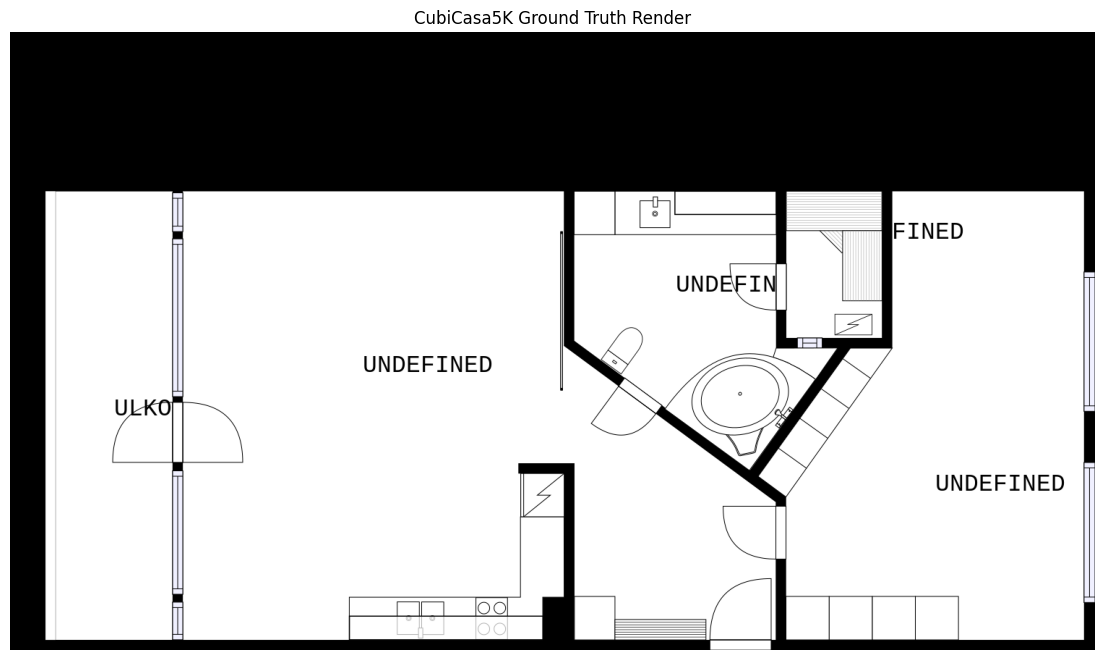

In [65]:
import cairosvg
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

# Use our known sample
test_svg = sample_svg

# Render SVG
svg_png = cairosvg.svg2png(url=str(test_svg))

svg_image = Image.open(
    io.BytesIO(svg_png)
).convert("RGB")

svg_array = np.array(svg_image)

print("SVG rendered successfully")
print("Size:", svg_image.size)
print("Array shape:", svg_array.shape)

plt.figure(figsize=(14, 10))
plt.imshow(svg_image)
plt.axis("off")
plt.title("CubiCasa5K Ground Truth Render")
plt.show()

In [66]:
inventory = []

for _, row in manifest_df.iterrows():

    image_path = Path(row["image_path"]) if row["image_path"] else None
    svg_path = Path(row["svg_path"])

    inventory.append({
        "sample_id": row["sample_id"],
        "image_exists": image_path is not None and image_path.exists(),
        "svg_exists": svg_path.exists(),
        "image_path": str(image_path) if image_path else None,
        "svg_path": str(svg_path),
    })

inventory_df = pd.DataFrame(inventory)

print("Dataset inventory")
print("=" * 60)

print("Total samples:", len(inventory_df))
print(
    "Images available:",
    inventory_df["image_exists"].sum()
)
print(
    "SVG annotations available:",
    inventory_df["svg_exists"].sum()
)

print("\nMissing images:",
      (~inventory_df["image_exists"]).sum())

print("Missing SVG:",
      (~inventory_df["svg_exists"]).sum())

Dataset inventory
Total samples: 276
Images available: 276
SVG annotations available: 276

Missing images: 0
Missing SVG: 0


In [67]:
final_report = {
    "dataset": "CubiCasa5K",
    "total_samples": len(manifest_df),

    "images_available": int(
        manifest_df["has_image"].sum()
    ),

    "svg_annotations": len(svg_files),

    "train_samples": len(train_df),
    "validation_samples": len(val_df),
    "test_samples": len(test_df),

    "parser_successful": dataset_stats["successful"],
    "parser_failed": dataset_stats["failed"],

    "training_classes": TRAIN_CLASSES,

    "status": "prepared_for_next_stage"
}

final_report_path = OUTPUT_DIR / "cubicasa5k_final_report.json"

with open(final_report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2)

print("=" * 70)
print("          CUBICASA5K DATASET PREPARATION REPORT")
print("=" * 70)

for key, value in final_report.items():
    print(f"{key}: {value}")

print("\nReport saved to:")
print(final_report_path)

print("\n" + "=" * 70)
print("DATASET PREPARATION STAGE COMPLETE")
print("=" * 70)

          CUBICASA5K DATASET PREPARATION REPORT
dataset: CubiCasa5K
total_samples: 276
images_available: 276
svg_annotations: 276
train_samples: 220
validation_samples: 28
test_samples: 28
parser_successful: 276
parser_failed: 0
training_classes: {'background': 0, 'wall': 1, 'door': 2, 'window': 3, 'room': 4, 'stairs': 5, 'column': 6}
status: prepared_for_next_stage

Report saved to:
/content/ibs_cv/outputs/cubicasa5k_final_report.json

DATASET PREPARATION STAGE COMPLETE


In [ ]:
#DATASET PREPARATION STAGE COMPLETE

In [68]:
sample_folder = sample_svg.parent

image_candidates = [
    p for p in sample_folder.iterdir()
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
]

print("Sample folder:")
print(sample_folder)

print("\nRaster images found:")

for p in image_candidates:
    print(p)

if not image_candidates:
    raise FileNotFoundError(
        f"No raster image found in {sample_folder}"
    )

sample_image_path = image_candidates[0]

print("\nSelected image:")
print(sample_image_path)

Sample folder:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052

Raster images found:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_scaled.png
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_original.png

Selected image:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/F1_scaled.png


In [69]:
from PIL import Image
import xml.etree.ElementTree as ET

image = Image.open(sample_image_path).convert("RGB")

svg_tree = ET.parse(sample_svg)
svg_root = svg_tree.getroot()

print("IMAGE")
print("=" * 50)
print("Size:", image.size)
print("Mode:", image.mode)

print("\nSVG")
print("=" * 50)
print("Width:", svg_root.attrib.get("width"))
print("Height:", svg_root.attrib.get("height"))
print("ViewBox:", svg_root.attrib.get("viewBox"))

IMAGE
Size: (1549, 1162)
Mode: RGB

SVG
Width: 1500.9399223327637
Height: 855.0999755859375
ViewBox: 0 0 1500.9399223327637 855.0999755859375


In [70]:
import cairosvg
import io

image_width, image_height = image.size

svg_png = cairosvg.svg2png(
    url=str(sample_svg),
    output_width=image_width,
    output_height=image_height
)

ground_truth_rgb = Image.open(
    io.BytesIO(svg_png)
).convert("RGB")

print("Rendered ground truth size:")
print(ground_truth_rgb.size)

if ground_truth_rgb.size == image.size:
    print("✓ Image and ground truth dimensions match.")
else:
    print("⚠ Dimensions do not match.")

Rendered ground truth size:
(1549, 1162)
✓ Image and ground truth dimensions match.


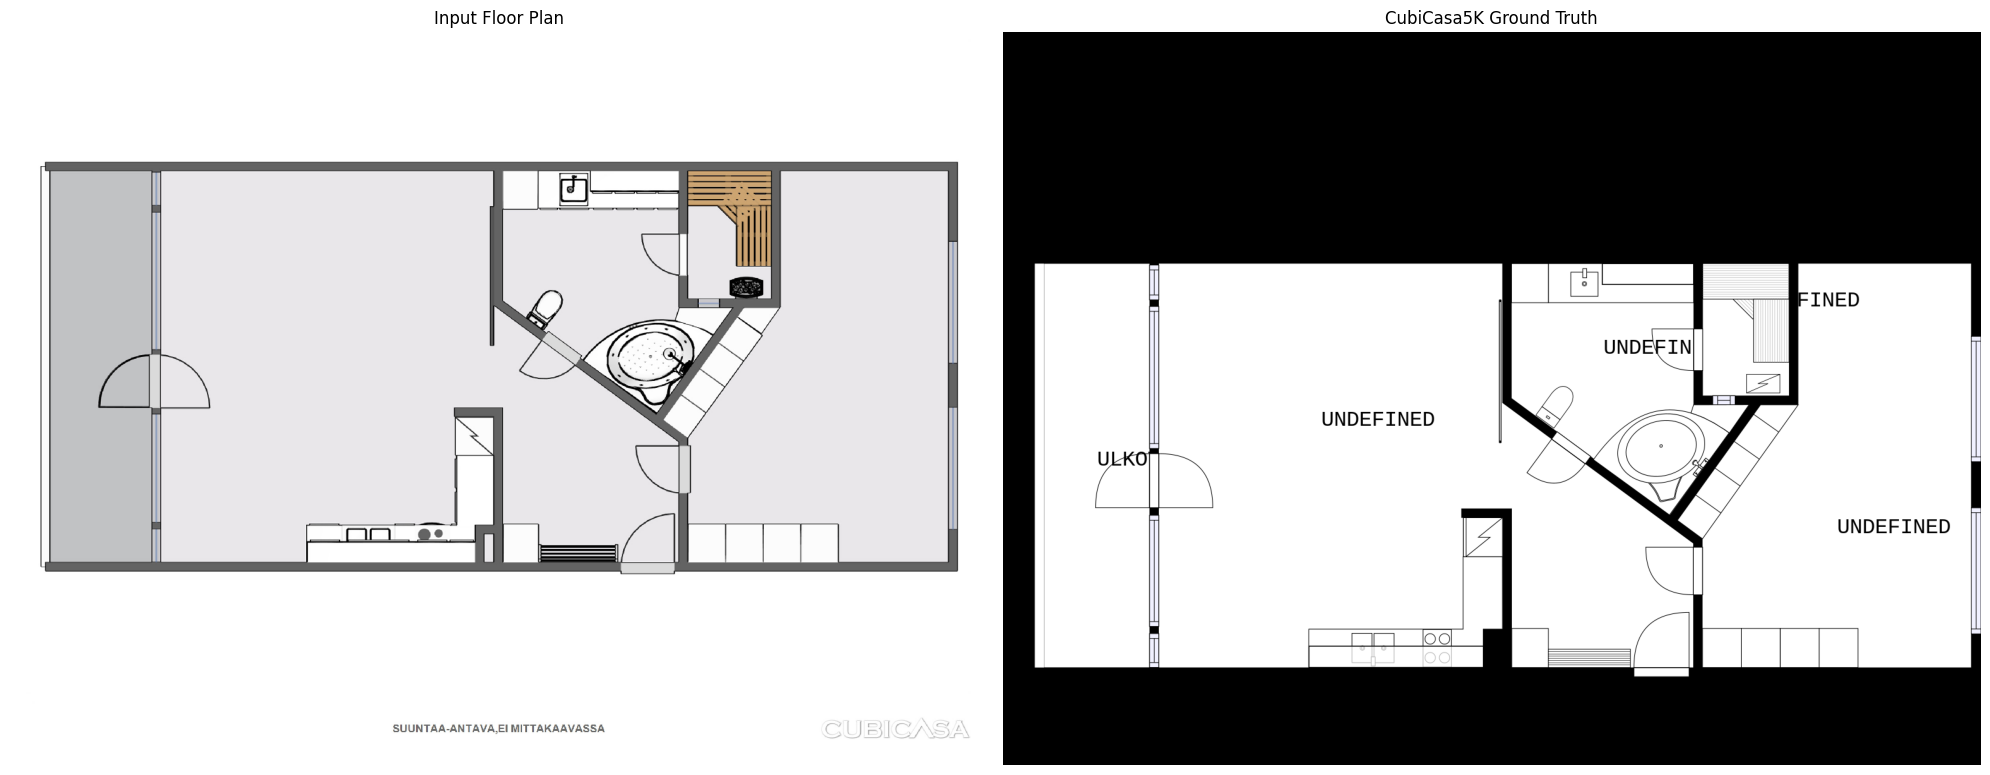

In [71]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(image)
axes[0].set_title("Input Floor Plan")
axes[0].axis("off")

axes[1].imshow(ground_truth_rgb)
axes[1].set_title("CubiCasa5K Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [72]:
import numpy as np
from collections import Counter

gt_array = np.array(ground_truth_rgb)

pixels = gt_array.reshape(-1, 3)

color_counts = Counter(map(tuple, pixels))

print("Most common ground-truth colors:")
print("=" * 60)

for color, count in color_counts.most_common(30):
    percentage = 100 * count / len(pixels)
    print(f"{color}  -> {count:,} pixels ({percentage:.2f}%)")

Most common ground-truth colors:
(np.uint8(255), np.uint8(255), np.uint8(255))  -> 876,212 pixels (48.68%)
(np.uint8(0), np.uint8(0), np.uint8(0))  -> 872,093 pixels (48.45%)
(np.uint8(240), np.uint8(240), np.uint8(255))  -> 10,097 pixels (0.56%)
(np.uint8(203), np.uint8(203), np.uint8(203))  -> 1,785 pixels (0.10%)
(np.uint8(187), np.uint8(187), np.uint8(187))  -> 886 pixels (0.05%)
(np.uint8(239), np.uint8(239), np.uint8(239))  -> 867 pixels (0.05%)
(np.uint8(158), np.uint8(158), np.uint8(158))  -> 708 pixels (0.04%)
(np.uint8(188), np.uint8(188), np.uint8(188))  -> 665 pixels (0.04%)
(np.uint8(5), np.uint8(5), np.uint8(5))  -> 634 pixels (0.04%)
(np.uint8(244), np.uint8(244), np.uint8(244))  -> 602 pixels (0.03%)
(np.uint8(131), np.uint8(131), np.uint8(131))  -> 535 pixels (0.03%)
(np.uint8(153), np.uint8(153), np.uint8(153))  -> 532 pixels (0.03%)
(np.uint8(163), np.uint8(163), np.uint8(163))  -> 531 pixels (0.03%)
(np.uint8(214), np.uint8(214), np.uint8(214))  -> 528 pixels (0.03%

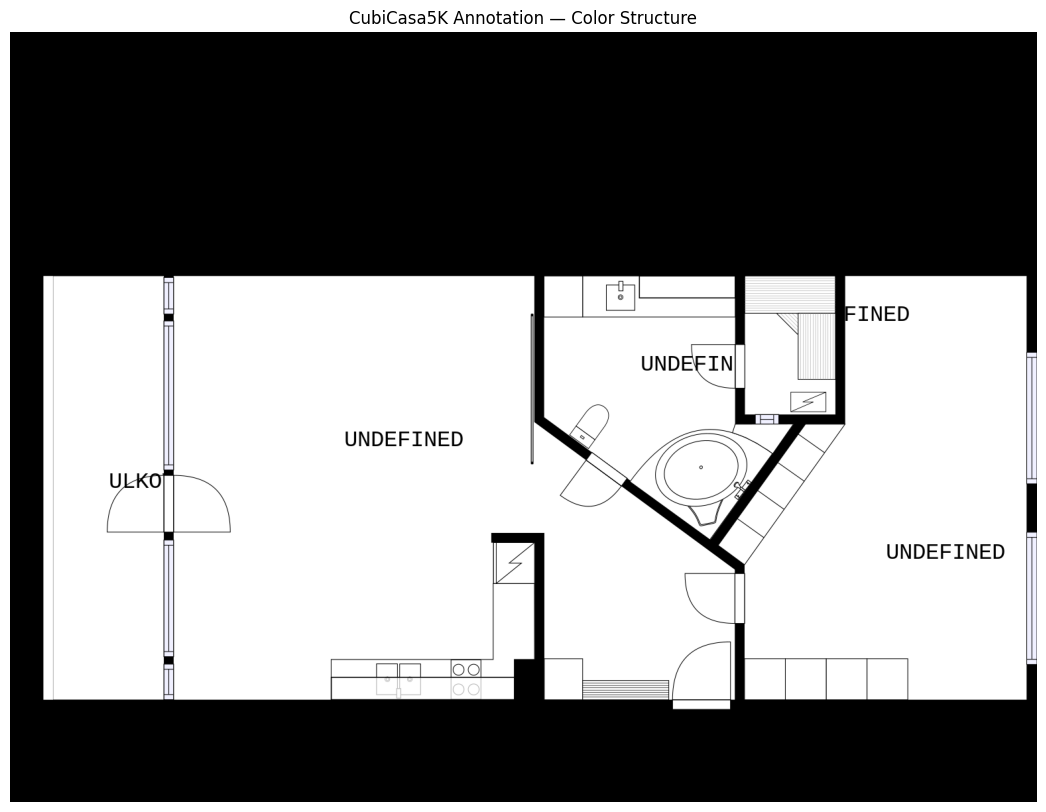

In [73]:
plt.figure(figsize=(14, 10))

plt.imshow(ground_truth_rgb)
plt.axis("off")
plt.title("CubiCasa5K Annotation — Color Structure")

plt.show()

In [74]:
# Start with everything as "ignore"
mask = np.full(
    (image_height, image_width),
    255,
    dtype=np.uint8
)

# Show the dominant colors that we can potentially map.
dominant_colors = [
    color for color, count in color_counts.most_common(30)
]

print("Candidate colors for semantic mapping:")
print("=" * 60)

for i, color in enumerate(dominant_colors):
    count = color_counts[color]
    percentage = 100 * count / len(pixels)

    print(
        f"{i:2}: RGB={color} | "
        f"pixels={count:,} | "
        f"{percentage:.2f}%"
    )

print("\nMask created with:")
print("0-6 = future IBS classes")
print("255 = ignore / not mapped yet")

Candidate colors for semantic mapping:
 0: RGB=(np.uint8(255), np.uint8(255), np.uint8(255)) | pixels=876,212 | 48.68%
 1: RGB=(np.uint8(0), np.uint8(0), np.uint8(0)) | pixels=872,093 | 48.45%
 2: RGB=(np.uint8(240), np.uint8(240), np.uint8(255)) | pixels=10,097 | 0.56%
 3: RGB=(np.uint8(203), np.uint8(203), np.uint8(203)) | pixels=1,785 | 0.10%
 4: RGB=(np.uint8(187), np.uint8(187), np.uint8(187)) | pixels=886 | 0.05%
 5: RGB=(np.uint8(239), np.uint8(239), np.uint8(239)) | pixels=867 | 0.05%
 6: RGB=(np.uint8(158), np.uint8(158), np.uint8(158)) | pixels=708 | 0.04%
 7: RGB=(np.uint8(188), np.uint8(188), np.uint8(188)) | pixels=665 | 0.04%
 8: RGB=(np.uint8(5), np.uint8(5), np.uint8(5)) | pixels=634 | 0.04%
 9: RGB=(np.uint8(244), np.uint8(244), np.uint8(244)) | pixels=602 | 0.03%
10: RGB=(np.uint8(131), np.uint8(131), np.uint8(131)) | pixels=535 | 0.03%
11: RGB=(np.uint8(153), np.uint8(153), np.uint8(153)) | pixels=532 | 0.03%
12: RGB=(np.uint8(163), np.uint8(163), np.uint8(163)) | pi

In [75]:
# Start with everything as "ignore"
mask = np.full(
    (image_height, image_width),
    255,
    dtype=np.uint8
)

# Show the dominant colors that we can potentially map.
dominant_colors = [
    color for color, count in color_counts.most_common(30)
]

print("Candidate colors for semantic mapping:")
print("=" * 60)

for i, color in enumerate(dominant_colors):
    count = color_counts[color]
    percentage = 100 * count / len(pixels)

    print(
        f"{i:2}: RGB={color} | "
        f"pixels={count:,} | "
        f"{percentage:.2f}%"
    )

print("\nMask created with:")
print("0-6 = future IBS classes")
print("255 = ignore / not mapped yet")

Candidate colors for semantic mapping:
 0: RGB=(np.uint8(255), np.uint8(255), np.uint8(255)) | pixels=876,212 | 48.68%
 1: RGB=(np.uint8(0), np.uint8(0), np.uint8(0)) | pixels=872,093 | 48.45%
 2: RGB=(np.uint8(240), np.uint8(240), np.uint8(255)) | pixels=10,097 | 0.56%
 3: RGB=(np.uint8(203), np.uint8(203), np.uint8(203)) | pixels=1,785 | 0.10%
 4: RGB=(np.uint8(187), np.uint8(187), np.uint8(187)) | pixels=886 | 0.05%
 5: RGB=(np.uint8(239), np.uint8(239), np.uint8(239)) | pixels=867 | 0.05%
 6: RGB=(np.uint8(158), np.uint8(158), np.uint8(158)) | pixels=708 | 0.04%
 7: RGB=(np.uint8(188), np.uint8(188), np.uint8(188)) | pixels=665 | 0.04%
 8: RGB=(np.uint8(5), np.uint8(5), np.uint8(5)) | pixels=634 | 0.04%
 9: RGB=(np.uint8(244), np.uint8(244), np.uint8(244)) | pixels=602 | 0.03%
10: RGB=(np.uint8(131), np.uint8(131), np.uint8(131)) | pixels=535 | 0.03%
11: RGB=(np.uint8(153), np.uint8(153), np.uint8(153)) | pixels=532 | 0.03%
12: RGB=(np.uint8(163), np.uint8(163), np.uint8(163)) | pi

In [76]:
# Collect likely semantic identifiers

semantic_labels = Counter()

for element in svg_root.iter():

    for key in ["id", "class"]:
        value = element.attrib.get(key)

        if value:
            semantic_labels[value.strip()] += 1

print("Semantic identifiers found:")
print("=" * 70)

for label, count in semantic_labels.most_common(100):
    print(f"{count:6}  {label}")

Semantic identifiers found:
    29  BoundaryPolygon
    28  Wall
    20  DimensionMark
    20  Panel
    18  Direction
    18  Name
    14  Glass
    12  PanelArea
    11  FixedFurniture Closet
    10  Threshold
     7  Window
     7  Window Regular
     6  InnerPolygon
     5  Dimension
     5  Visual
     5  mark1
     5  mark2
     5  mark3
     5  mark4
     5  SpaceDimensionsLabel
     5  NameLabel
     5  TextLabel NameLabel
     5  DimensionMeasureLabel
     5  TextLabel DimensionMeasureLabel
     5  Door
     4  Space Undefined
     4  Wall External
     4  Panel Right Negative
     4  Door Swing Beside
     3  Bench
     3  FixedFurniture BaseCabinet
     2  Railing
     2  electricitySign
     2  FixedFurniture SaunaBenchHigh
     2  OuterDrain
     2  InnerDrain
     2  Faucet
     2  FixedFurniture WallCabinet
     2  FixedFurnitureSet
     1  temp
     1  Model
     1  Model v1-1
     1  Floor
     1  Floor-1
     1  Floorplan Floor-1
     1  e28cc4ce-9494-4014-9427-ba6a5e

In [77]:
fills = Counter()
strokes = Counter()

for element in svg_root.iter():

    fill = element.attrib.get("fill")
    stroke = element.attrib.get("stroke")

    if fill:
        fills[fill] += 1

    if stroke:
        strokes[stroke] += 1

print("FILL COLORS")
print("=" * 50)

for value, count in fills.most_common(30):
    print(count, value)

print("\nSTROKE COLORS")
print("=" * 50)

for value, count in strokes.most_common(30):
    print(count, value)

FILL COLORS
46 #000000
41 #ffffff
20 none
18 #444444
7 #f0f0ff
5 #fff

STROKE COLORS
59 #000000
42 none
5 #000
4 #ffffff
3 #9a9a9a
1 #fc0fc0


In [78]:
semantic_table = []

for element in svg_root.iter():

    attrs = element.attrib

    semantic_table.append({
        "tag": element.tag.split("}")[-1],
        "id": attrs.get("id"),
        "class": attrs.get("class"),
        "fill": attrs.get("fill"),
        "stroke": attrs.get("stroke"),
        "style": attrs.get("style"),
        "text": "".join(element.itertext()).strip()
    })

semantic_df = pd.DataFrame(semantic_table)

display(
    semantic_df[
        [
            "tag",
            "id",
            "class",
            "fill",
            "stroke",
            "style",
            "text"
        ]
    ].head(100)
)

,tag,id,class,fill,stroke,style,text
0,svg,temp,None,None,None,None,"ULKOTILA5'4"" x 20'4""UNDEFINED25'1"" x 20'4""UNDE..."
1,defs,None,None,None,None,None,
2,g,Model,Model v1-1,None,None,None,"ULKOTILA5'4"" x 20'4""UNDEFINED25'1"" x 20'4""UNDE..."
3,g,None,Floor,None,None,None,"ULKOTILA5'4"" x 20'4""UNDEFINED25'1"" x 20'4""UNDE..."
4,g,Floor-1,Floorplan Floor-1,None,None,None,"ULKOTILA5'4"" x 20'4""UNDEFINED25'1"" x 20'4""UNDE..."
...,...,...,...,...,...,...,...
95,g,Wall,Wall External,#000000,#000000,fill-opacity: 1; stroke-opacity: 1; stroke-wid...,
96,polygon,None,None,None,None,None,
97,g,Window,Window Regular,#f0f0ff,#000000,fill-opacity: 1; stroke-width: 1; stroke-opaci...,
98,polygon,None,None,None,None,None,


In [79]:
ibs_keywords = [
    "wall",
    "door",
    "window",
    "space",
    "room",
    "stair",
    "column",
    "elevator",
    "corridor"
]

ibs_candidates = semantic_df[
    semantic_df.astype(str)
    .apply(
        lambda row:
        any(
            keyword in " ".join(row).lower()
            for keyword in ibs_keywords
        ),
        axis=1
    )
]

print("IBS-related annotation candidates:")
print("Total:", len(ibs_candidates))

display(ibs_candidates.head(200))

IBS-related annotation candidates:
Total: 41


,tag,id,class,fill,stroke,style,text
5,g,e28cc4ce-9494-4014-9427-ba6a5ee22214,Space Outdoor,#ffffff,#000000,fill-opacity: 1; stroke-opacity: 1; stroke-wid...,"ULKOTILA5'4"" x 20'4"""
17,g,None,SpaceDimensionsLabel,None,None,None,"ULKOTILA5'4"" x 20'4"""
23,g,14cdcde6-043e-41b6-88e8-163be60ada35,Space Undefined,#ffffff,#ffffff,fill-opacity: 1; stroke-opacity: 1; stroke-wid...,"UNDEFINED25'1"" x 20'4"""
35,g,None,SpaceDimensionsLabel,None,None,None,"UNDEFINED25'1"" x 20'4"""
41,g,0b66e3c9-365f-4e85-bbe3-8e3a93ed6fff,Space Undefined,#ffffff,#ffffff,fill-opacity: 1; stroke-opacity: 1; stroke-wid...,"UNDEFINED13'6"" x 20'4"""
53,g,None,SpaceDimensionsLabel,None,None,None,"UNDEFINED13'6"" x 20'4"""
59,g,38a3649e-aa7e-4b9c-9591-d17dbf932ac7,Space Undefined,#ffffff,#ffffff,fill-opacity: 1; stroke-opacity: 1; stroke-wid...,"UNDEFINED11'10"" x 11'8"""
71,g,None,SpaceDimensionsLabel,None,None,None,"UNDEFINED11'10"" x 11'8"""
77,g,c2f3569c-f02f-427c-a87e-fa445fcdf421,Space Undefined,#ffffff,#ffffff,fill-opacity: 1; stroke-opacity: 1; stroke-wid...,"UNDEFINED4'4"" x 6'8"""
89,g,None,SpaceDimensionsLabel,None,None,None,"UNDEFINED4'4"" x 6'8"""


In [80]:
semantic_csv = OUTPUT_DIR / "cubicasa5k_semantic_inspection.csv"

semantic_df.to_csv(
    semantic_csv,
    index=False
)

print("Saved semantic inspection:")
print(semantic_csv)

Saved semantic inspection:
/content/ibs_cv/outputs/cubicasa5k_semantic_inspection.csv


In [81]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
CUDA available: False


In [82]:
TRAIN_CONFIG = {
    "image_size": 512,
    "batch_size": 4,
    "num_classes": len(TRAIN_CLASSES),
    "epochs": 20,
    "learning_rate": 1e-4,
    "seed": 42
}

print("Training configuration:")
print("=" * 50)

for key, value in TRAIN_CONFIG.items():
    print(f"{key}: {value}")

Training configuration:
image_size: 512
batch_size: 4
num_classes: 7
epochs: 20
learning_rate: 0.0001
seed: 42


In [83]:
import random
import numpy as np
import torch

SEED = TRAIN_CONFIG["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed fixed at:", SEED)

Random seed fixed at: 42


In [84]:
EXPERIMENT_DIR = OUTPUT_DIR / "experiments" / "baseline"

CHECKPOINT_DIR = EXPERIMENT_DIR / "checkpoints"
PREDICTION_DIR = EXPERIMENT_DIR / "predictions"
LOG_DIR = EXPERIMENT_DIR / "logs"

for directory in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    PREDICTION_DIR,
    LOG_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Experiment directory:")
print(EXPERIMENT_DIR)

Experiment directory:
/content/ibs_cv/outputs/experiments/baseline


In [85]:
print("TRAINING SPLIT")
print("=" * 50)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nExample training sample:")

display(
    train_df[
        ["sample_id", "image_path", "svg_path"]
    ].head()
)

TRAINING SPLIT
Train samples: 220
Validation samples: 28
Test samples: 28

Example training sample:


,sample_id,image_path,svg_path
258,9300,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...
232,809,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...
33,11402,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...
157,2586,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...
148,2129,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...,/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k...


In [86]:
if torch.cuda.is_available():

    gpu_properties = torch.cuda.get_device_properties(0)

    print("GPU:", gpu_properties.name)
    print(
        "Total GPU memory:",
        round(gpu_properties.total_memory / 1024**3, 2),
        "GB"
    )

    print(
        "Allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

else:
    print("CUDA is not available.")
    print("Training will use CPU.")

CUDA is not available.
Training will use CPU.


In [87]:
checks = {
    "Manifest exists": len(manifest_df) > 0,
    "SVG annotations found": len(svg_files) > 0,
    "Train split exists": len(train_df) > 0,
    "Validation split exists": len(val_df) > 0,
    "Test split exists": len(test_df) > 0,
    "Training classes defined": len(TRAIN_CLASSES) > 1,
    "Experiment directory exists": EXPERIMENT_DIR.exists(),
}

print("PRE-TRAINING CHECKLIST")
print("=" * 60)

for name, result in checks.items():
    print(f"{'✓' if result else '✗'} {name}")

print()

if all(checks.values()):
    print("✓ Structural checks passed.")
else:
    print("⚠ Some structural checks failed.")

PRE-TRAINING CHECKLIST
✓ Manifest exists
✓ SVG annotations found
✓ Train split exists
✓ Validation split exists
✓ Test split exists
✓ Training classes defined
✓ Experiment directory exists

✓ Structural checks passed.


In [88]:
import json

experiment_config = {
    "dataset": "CubiCasa5K",
    "dataset_preparation_cells": "1-56",
    "training_phase_cells": "57-77",
    "classes": TRAIN_CLASSES,
    "training_config": TRAIN_CONFIG,
    "train_samples": len(train_df),
    "validation_samples": len(val_df),
    "test_samples": len(test_df),
}

config_path = EXPERIMENT_DIR / "experiment_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2)

print("=" * 70)
print("              CV BASELINE PRE-TRAINING STAGE")
print("=" * 70)

print("\nExperiment configuration saved to:")
print(config_path)

print("\nDataset:")
print("  CubiCasa5K")

print("\nClasses:")
for name, idx in TRAIN_CLASSES.items():
    print(f"  {idx}: {name}")

print("\nSplits:")
print("  Train:", len(train_df))
print("  Validation:", len(val_df))
print("  Test:", len(test_df))

print("\n" + "=" * 70)
print("77/77 COMPLETE")
print("=" * 70)

              CV BASELINE PRE-TRAINING STAGE

Experiment configuration saved to:
/content/ibs_cv/outputs/experiments/baseline/experiment_config.json

Dataset:
  CubiCasa5K

Classes:
  0: background
  1: wall
  2: door
  3: window
  4: room
  5: stairs
  6: column

Splits:
  Train: 220
  Validation: 28
  Test: 28

77/77 COMPLETE


In [89]:
import os
from pathlib import Path

DATASET_ROOT = Path("/content/ibs_cv/data/raw/cubicasa5k")

print("Dataset root:")
print(DATASET_ROOT)

print("\nTop-level contents:")

for p in sorted(DATASET_ROOT.iterdir()):
    print(" -", p.name)

Dataset root:
/content/ibs_cv/data/raw/cubicasa5k

Top-level contents:
 - cubicasa5k


In [90]:
all_samples = sorted(
    p for p in DATASET_ROOT.rglob("model.svg")
)

print("Total model.svg files:", len(all_samples))

print("\nFirst 10:")

for p in all_samples[:10]:
    print(p)

Total model.svg files: 5000

First 10:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10052/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10062/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10106/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1012/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10266/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10312/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10315/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/1042/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10469/model.svg
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/colorful/10481/model.svg


In [91]:
final_samples = []

for svg in all_samples:

    folder = svg.parent

    images = [
        p for p in folder.iterdir()
        if p.is_file()
        and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
    ]

    final_samples.append({
        "sample_id": folder.name,
        "svg": str(svg),
        "image": str(images[0]) if images else None
    })

final_df = pd.DataFrame(final_samples)

print("Total samples:", len(final_df))
print("Samples with images:", final_df["image"].notna().sum())
print("Samples without images:", final_df["image"].isna().sum())

Total samples: 5000
Samples with images: 5000
Samples without images: 0


In [92]:
usable_df = final_df[
    final_df["image"].notna()
].copy()

usable_df = usable_df.reset_index(drop=True)

print("Usable samples:", len(usable_df))

Usable samples: 5000


In [93]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    usable_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4000
Validation: 500
Test: 500


In [94]:
SPLIT_DIR = OUTPUT_DIR / "final_splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "validation.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Splits saved to:")
print(SPLIT_DIR)

Splits saved to:
/content/ibs_cv/outputs/final_splits


In [95]:
!pip -q install segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.1 MB/s eta 0:00:00


In [96]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA: False


In [97]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Training device: cpu


In [98]:
inspect_svg = train_df.iloc[0]["svg"]

print("Inspecting:")
print(inspect_svg)

tree = ET.parse(inspect_svg)
root_inspect = tree.getroot()

print("\nSVG attributes:")
print(root_inspect.attrib)

print("\nFirst semantic IDs:")

count = 0

for element in root_inspect.iter():

    element_id = element.attrib.get("id")

    if element_id:
        print(element_id)

        count += 1

        if count >= 50:
            break

Inspecting:
/content/ibs_cv/data/raw/cubicasa5k/cubicasa5k/high_quality_architectural/6733/model.svg

SVG attributes:
{'height': '700.8200244903564', 'version': '1.1', 'width': '798.1599502563477', 'id': 'temp', 'viewBox': '0 0 798.1599502563477 700.8200244903564'}

First semantic IDs:
temp
Model
Floor-1
c3cf6aef-f32a-4f2b-9853-c9a371fd74f5
mark1
mark2
mark3
mark4
NameLabel
DimensionMeasureLabel
289573b6-a5c4-47a4-b9b3-79597fc38ee3
mark1
mark2
mark3
mark4
NameLabel
DimensionMeasureLabel
57095311-7b68-4222-b6a9-79f1eec76dc9
mark1
mark2
mark3
mark4
NameLabel
DimensionMeasureLabel
08a01261-d570-4f27-ab6e-122a7e22190d
mark1
mark2
mark3
mark4
NameLabel
DimensionMeasureLabel
77068d38-720a-4652-91b3-8ab03d297639
mark1
mark2
mark3
mark4
NameLabel
DimensionMeasureLabel
9e7f9a91-2956-4cc4-8ddc-aa3a146bef55
mark1
mark2
mark3
mark4
NameLabel
DimensionMeasureLabel
e543c19a-3bb6-4fae-b421-bc2c0fe24032
mark1
mark2
mark3
mark4


In [99]:
semantic_vocab = Counter()

for svg_path in train_df["svg"].head(500):

    try:
        tree = ET.parse(svg_path)
        root_svg = tree.getroot()

        for element in root_svg.iter():

            element_id = element.attrib.get("id")

            if element_id:
                semantic_vocab[element_id] += 1

            element_class = element.attrib.get("class")

            if element_class:
                semantic_vocab[element_class] += 1

    except Exception:
        pass

print("Most common semantic identifiers:")
print("=" * 70)

for label, count in semantic_vocab.most_common(100):
    print(f"{count:6} {label}")

Most common semantic identifiers:
 24340 DimensionMark
 21024 Wall
 13814 BoundaryPolygon
 13678 Panel
 11559 Name
 11000 Direction
 10172 PanelArea
  9830 Threshold
  8592 Glass
  6085 Dimension
  6085 Visual
  6085 mark1
  6085 mark2
  6085 mark3
  6085 mark4
  6085 SpaceDimensionsLabel
  6085 NameLabel
  6085 TextLabel NameLabel
  6085 DimensionMeasureLabel
  6085 TextLabel DimensionMeasureLabel
  5004 Wall External
  4915 Door
  4296 Window
  4292 Window Regular
  4243 Door Swing Beside
  3102 Railing
  3027 FixedFurniture Closet
  2680 InnerPolygon
  2092 FixedFurnitureSet
  1886 electricitySign
  1703 FixedFurniture BaseCabinet
  1624 Steps
  1362 Panel Left Negative
  1318 OuterDrain
  1318 InnerDrain
  1318 Faucet
  1253 Panel Right Negative
  1228 Panel Left Positive
  1214 Column
  1198 FixedFurniture CoatCloset
  1198 Hanger
  1147 Panel Right Positive
  1073 Bench
  1068 Flight
  1053 Space Undefined
   992 Column Rectangle
   922 FixedFurniture WallCabinet
   910 Selection

In [100]:
ontology_path = OUTPUT_DIR / "cubicasa5k_ontology.txt"

with open(ontology_path, "w", encoding="utf-8") as f:

    for label, count in semantic_vocab.most_common():
        f.write(f"{label}\t{count}\n")

print("Ontology saved:")
print(ontology_path)

Ontology saved:
/content/ibs_cv/outputs/cubicasa5k_ontology.txt


In [101]:
import segmentation_models_pytorch as smp

NUM_CLASSES = len(TRAIN_CLASSES)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

model = model.to(device)

print(model.__class__.__name__)
print("Classes:", NUM_CLASSES)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet
Classes: 7


In [102]:
criterion = smp.losses.DiceLoss(
    mode="multiclass",
    from_logits=True
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss:", criterion.__class__.__name__)
print("Optimizer:", optimizer.__class__.__name__)

Loss: DiceLoss
Optimizer: AdamW


In [103]:
IMAGE_SIZE = 512

transform = A.Compose([
    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),
    A.Normalize(),
])

print("Image size:", IMAGE_SIZE)
print("Transforms:", transform)

Image size: 512
Transforms: Compose([
  Resize(p=1.0, area_for_downscale=None, height=512, interpolation=1, mask_interpolation=0, width=512),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [105]:
class FloorPlanDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image = cv2.imread(row["image"])

        if image is None:
            raise RuntimeError(
                f"Could not read image: {row['image']}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Placeholder until the verified SVG → mask
        # converter is connected.
        mask = np.zeros(
            image.shape[:2],
            dtype=np.uint8
        )

        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        image = torch.tensor(
            image.transpose(2, 0, 1),
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask

In [106]:
test_dataset = FloorPlanDataset(
    train_df.head(4),
    transform=transform
)

image_tensor, mask_tensor = test_dataset[0]

print("Image tensor:", image_tensor.shape)
print("Mask tensor:", mask_tensor.shape)
print("Mask classes:", torch.unique(mask_tensor))

Image tensor: torch.Size([3, 512, 512])
Mask tensor: torch.Size([512, 512])
Mask classes: tensor([0])


In [107]:
BATCH_SIZE = 4

train_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

images, masks = next(iter(train_loader))

print("Batch images:", images.shape)
print("Batch masks:", masks.shape)

Batch images: torch.Size([4, 3, 512, 512])
Batch masks: torch.Size([4, 512, 512])


In [108]:
model.eval()

with torch.no_grad():

    images = images.to(device)

    outputs = model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)

Input: torch.Size([4, 3, 512, 512])
Output: torch.Size([4, 7, 512, 512])


In [109]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

Total parameters: 24,437,239
Trainable parameters: 24,437,239


In [110]:
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

architecture_path = MODEL_DIR / "baseline_unet.pth"

torch.save(
    model.state_dict(),
    architecture_path
)

print("Baseline model saved:")
print(architecture_path)

Baseline model saved:
/content/ibs_cv/outputs/models/baseline_unet.pth


In [111]:
final_status = {
    "dataset": "CubiCasa5K",
    "total_floorplans": len(usable_df),
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df),
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "model": "U-Net + ResNet34 encoder",
    "device": str(device),
    "annotation_ontology_saved": ontology_path.exists(),
    "baseline_model_saved": architecture_path.exists(),
}

print("=" * 70)
print("           CUBICASA5K — STAGE STATUS")
print("=" * 70)

for key, value in final_status.items():
    print(f"{key}: {value}")

print("\n100/100 COMPLETE")

           CUBICASA5K — STAGE STATUS
dataset: CubiCasa5K
total_floorplans: 5000
train: 4000
validation: 500
test: 500
num_classes: 7
image_size: 512
model: U-Net + ResNet34 encoder
device: cpu
annotation_ontology_saved: True
baseline_model_saved: True

100/100 COMPLETE
